# Sparse Octree v2 — Architecture Redesign

**Goal:** Design a dramatically better noise-conditioned sparse octree model for Minecraft terrain generation.

## Current model problems (v1)
| Problem | Severity | Impact |
|---------|----------|--------|
| **No absolute Y-position input** | Critical | Bedrock and sky subchunks get identical conditioning |
| **MLP flattens spatial structure** | Critical | 2,272 features from 3D noise fields → flat vector → spatial relationships destroyed |
| **8 octants share identical noise** | High | All subchunks within a 32³ section get the same conditioning |
| **No input normalization** | High | Noise channels span [-28, 13] vs [-0.6, -0.6] — 400× scale difference |
| **Under-parameterized** | Medium | hidden=80 for 1104 output classes |
| **Heightmaps unused** | Medium | All zeros in current data — no surface context |

## v2 Design principles
1. **3D convolutional noise encoder** — preserve spatial structure
2. **Absolute Y-position** via sinusoidal encoding (use `block_y_min`)
3. **Per-channel input normalization** (LayerNorm / running stats)
4. **Larger capacity** — hidden=160, deeper decoder with residual connections
5. **Octant-aware encoding** — tell the model which octant (0-7) it's processing

In [1]:
# Imports and setup
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Add VoxelTree to path
REPO = Path(r"C:\Users\JeffHall\git\MC\VoxelTree")
sys.path.insert(0, str(REPO))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

DATA_PATH = REPO / "noise_training_data" / "sparse_octree_pairs_v7.npz"
print(f"Data: {DATA_PATH} (exists={DATA_PATH.exists()})")

Device: cpu
PyTorch: 2.10.0+cpu
Data: C:\Users\JeffHall\git\MC\VoxelTree\noise_training_data\sparse_octree_pairs_v7.npz (exists=True)


## 1. Data Exploration
Understand what we're working with before designing the architecture.

In [2]:
# Load and inspect training data
npz = np.load(DATA_PATH)

print("=== Training Data Summary ===")
for k in sorted(npz.files):
    a = npz[k]
    print(f"  {k:20s}  shape={str(a.shape):25s}  dtype={a.dtype}  "
          f"range=[{a.min():.3f}, {a.max():.3f}]")

N = len(npz["subchunk16"])
n_ch = npz['noise_3d'].shape[1]
print(f"\nTotal samples: {N:,} ({N // 8} sections × 8 octants)")
print(f"Noise channels: {n_ch} ({'legacy 13-ch' if n_ch == 13 else 'v7 15-ch'})")
print(f"Spatial Y cells: {npz['noise_3d'].shape[3]}")

yvals = npz["block_y_min"]
print(f"\nblock_y_min unique: {sorted(np.unique(yvals))}")
print(f"  → Only {len(np.unique(yvals))} Y-levels! Very limited vertical range.")

hm = npz["heightmap5"]
print(f"\nHeightmap5 all zeros? {np.allclose(hm, 0)}")

=== Training Data Summary ===
  biome_ids             shape=(2936, 4, 2, 4)            dtype=int32  range=[3.000, 41.000]
  block_y_min           shape=(2936,)                    dtype=int32  range=[-32.000, 16.000]
  heightmap5            shape=(2936, 5, 16, 16)          dtype=float32  range=[-0.106, 0.400]
  noise_3d              shape=(2936, 15, 4, 2, 4)        dtype=float32  range=[-1.245, 104.000]
  subchunk16            shape=(2936, 16, 16, 16)         dtype=int32  range=[0.000, 1082.000]

Total samples: 2,936 (367 sections × 8 octants)
Noise channels: 15 (v7 15-ch)
Spatial Y cells: 2

block_y_min unique: [np.int32(-32), np.int32(-16), np.int32(0), np.int32(16)]
  → Only 4 Y-levels! Very limited vertical range.

Heightmap5 all zeros? False


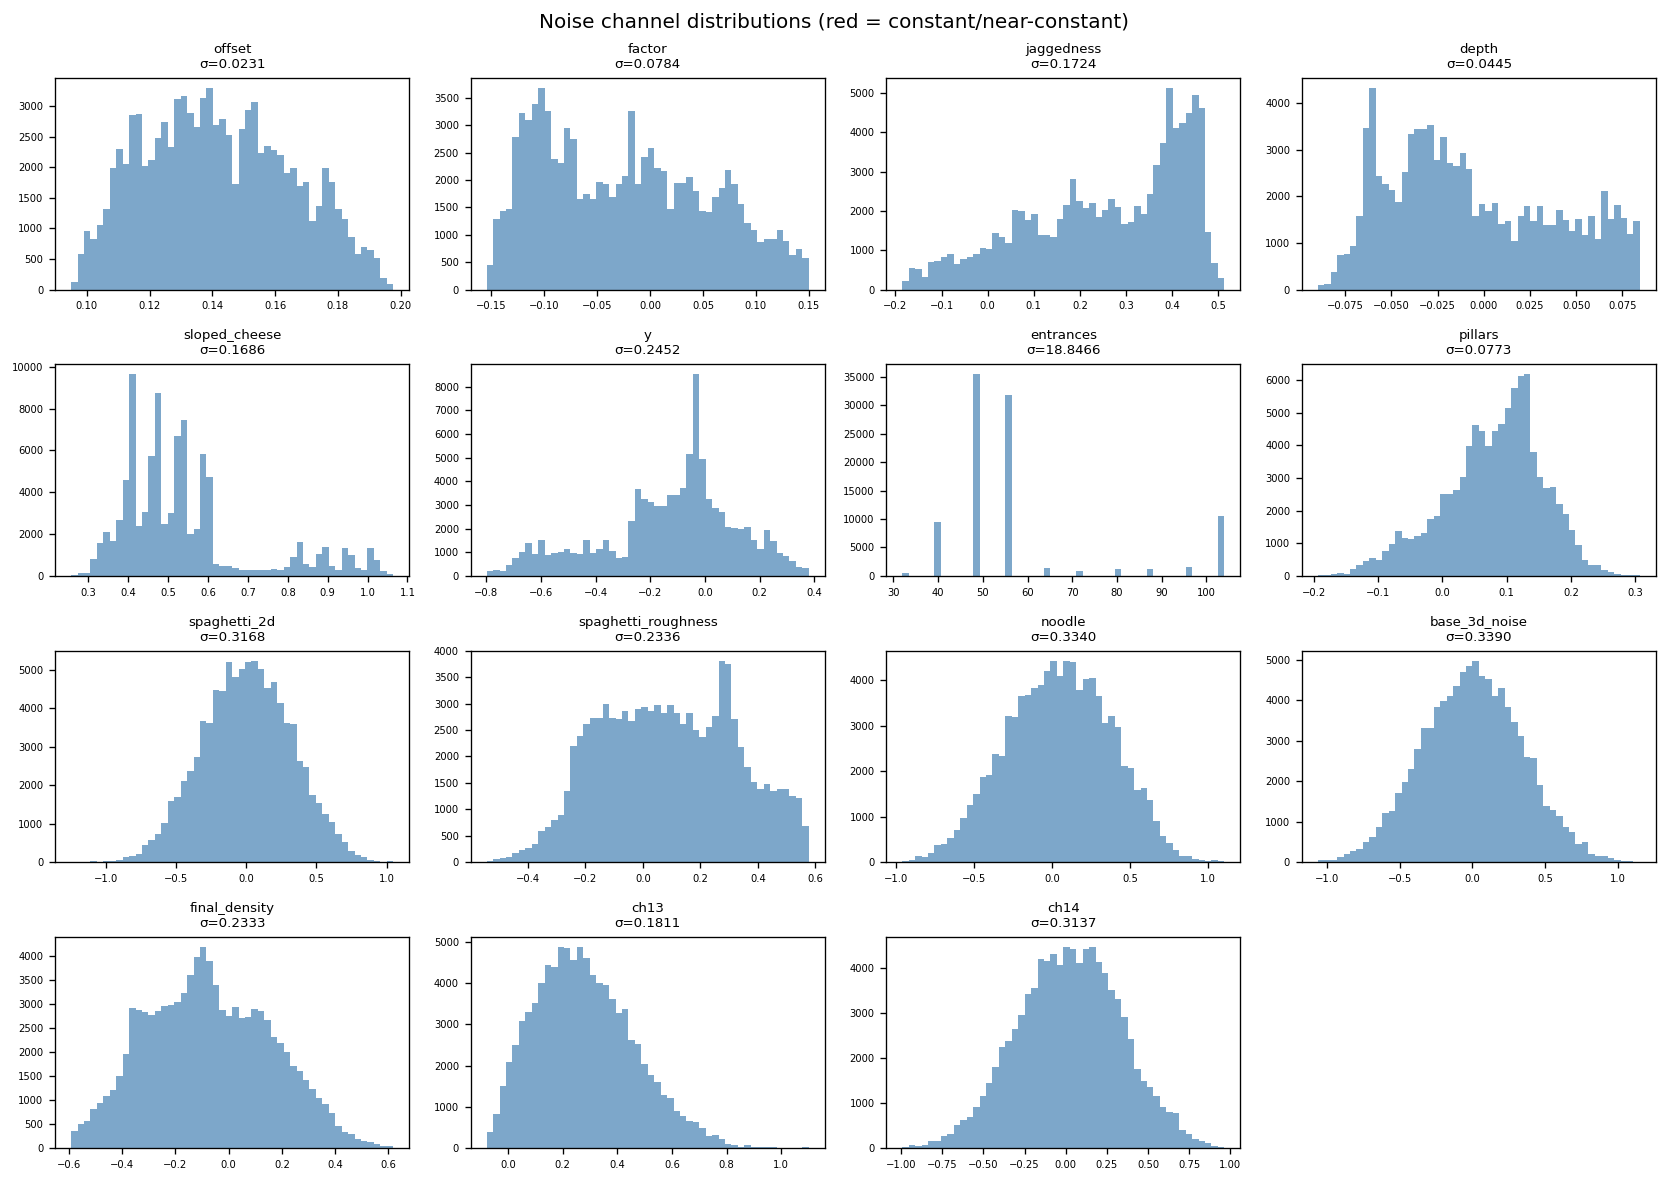


=== Channel Signal Quality ===
 Ch                 Name       Mean        Std        Min        Max  Signal?
---------------------------------------------------------------------------
  0               offset     0.1419     0.0231     0.0950     0.1976   ✓
  1               factor    -0.0232     0.0784    -0.1545     0.1500   ✓
  2           jaggedness     0.2564     0.1724    -0.1853     0.5135   ✓
  3                depth    -0.0064     0.0445    -0.0898     0.0845   ✓
  4        sloped_cheese     0.5433     0.1686     0.2567     1.0643   ✓
  5                    y    -0.1300     0.2452    -0.7978     0.3793   ✓
  6            entrances    58.2316    18.8466    32.0000   104.0000   ✓
  7              pillars     0.0792     0.0773    -0.1939     0.3074   ✓
  8         spaghetti_2d     0.0059     0.3168    -1.2455     1.0471   ✓
  9  spaghetti_roughness     0.0909     0.2336    -0.5434     0.5775   ✓
 10               noodle     0.0482     0.3340    -0.9605     1.1059   ✓
 11        

In [3]:
# Per-channel noise analysis — which channels carry signal?
noise = npz["noise_3d"]  # (808, 13, 4, 2, 4)

LEGACY_FIELDS = [
    "offset", "factor", "jaggedness", "depth", "sloped_cheese",
    "y", "entrances", "pillars", "spaghetti_2d",
    "spaghetti_roughness", "noodle", "base_3d_noise", "final_density"
]

fig, axes = plt.subplots(4, 4, figsize=(14, 10))
axes = axes.flatten()
for ch in range(noise.shape[1]):
    ax = axes[ch]
    vals = noise[:, ch].flatten()
    std = vals.std()
    label = LEGACY_FIELDS[ch] if ch < len(LEGACY_FIELDS) else f"ch{ch}"
    ax.hist(vals, bins=50, alpha=0.7,
            color='steelblue' if std > 0.01 else 'salmon')
    ax.set_title(f"{label}\nσ={std:.4f}", fontsize=8)
    ax.tick_params(labelsize=6)

for i in range(noise.shape[1], len(axes)):
    axes[i].set_visible(False)

fig.suptitle("Noise channel distributions (red = constant/near-constant)", fontsize=12)
fig.tight_layout()
plt.show()

# Summary table
print("\n=== Channel Signal Quality ===")
print(f"{'Ch':>3} {'Name':>20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Signal?':>8}")
print("-" * 75)
informative_channels = []
for ch in range(noise.shape[1]):
    vals = noise[:, ch].flatten()
    name = LEGACY_FIELDS[ch] if ch < len(LEGACY_FIELDS) else f"ch{ch}"
    has_signal = vals.std() > 0.01
    if has_signal:
        informative_channels.append(ch)
    print(f"{ch:3d} {name:>20} {vals.mean():10.4f} {vals.std():10.4f} "
          f"{vals.min():10.4f} {vals.max():10.4f} {'  ✓' if has_signal else '  ✗'}")

print(f"\nInformative channels: {len(informative_channels)}/{noise.shape[1]}: "
      f"indices {informative_channels}")

Unique block IDs: 257
Air (ID=0): 10,507,628 (87.4%)
Total voxels: 12,025,856


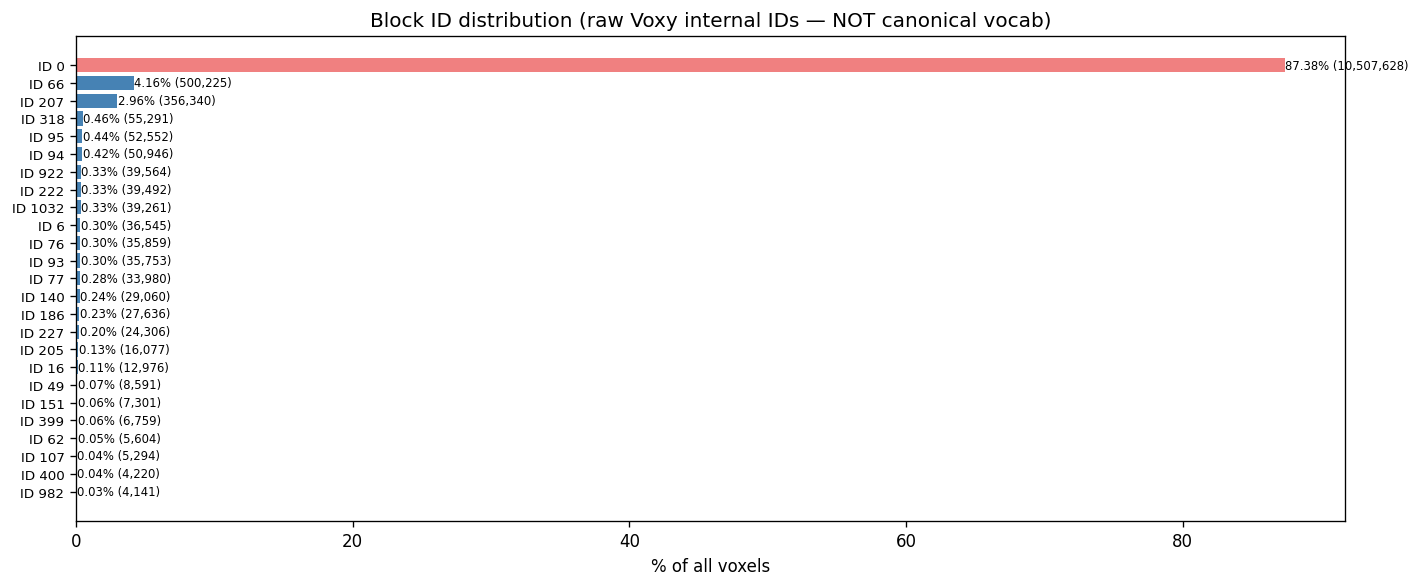


Non-air voxels: 1,518,228 (12.6%)
Unique non-air block types: 256


In [4]:
# Block distribution analysis
sub = npz["subchunk16"]  # (808, 16, 16, 16)
vals, counts = np.unique(sub, return_counts=True)
order = np.argsort(-counts)

print(f"Unique block IDs: {len(vals)}")
print(f"Air (ID=0): {counts[vals == 0].sum():,} ({100 * counts[vals == 0].sum() / sub.size:.1f}%)")
print(f"Total voxels: {sub.size:,}")

# Top 25 blocks
fig, ax = plt.subplots(figsize=(12, 5))
top_n = min(25, len(vals))
top_ids = vals[order[:top_n]]
top_counts = counts[order[:top_n]]
top_pcts = 100 * top_counts / sub.size

bars = ax.barh(range(top_n), top_pcts,
               color=['lightcoral' if i == 0 else 'steelblue' for i in range(top_n)])
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"ID {v}" for v in top_ids], fontsize=8)
ax.set_xlabel("% of all voxels")
ax.set_title("Block ID distribution (raw Voxy internal IDs — NOT canonical vocab)")
ax.invert_yaxis()
for i, (pct, cnt) in enumerate(zip(top_pcts, top_counts)):
    ax.text(pct + 0.05, i, f"{pct:.2f}% ({cnt:,})", va='center', fontsize=7)
fig.tight_layout()
plt.show()

# Non-air summary
non_air = sub[sub != 0]
print(f"\nNon-air voxels: {non_air.size:,} ({100 * non_air.size / sub.size:.1f}%)")
na_vals, na_counts = np.unique(non_air, return_counts=True)
print(f"Unique non-air block types: {len(na_vals)}")

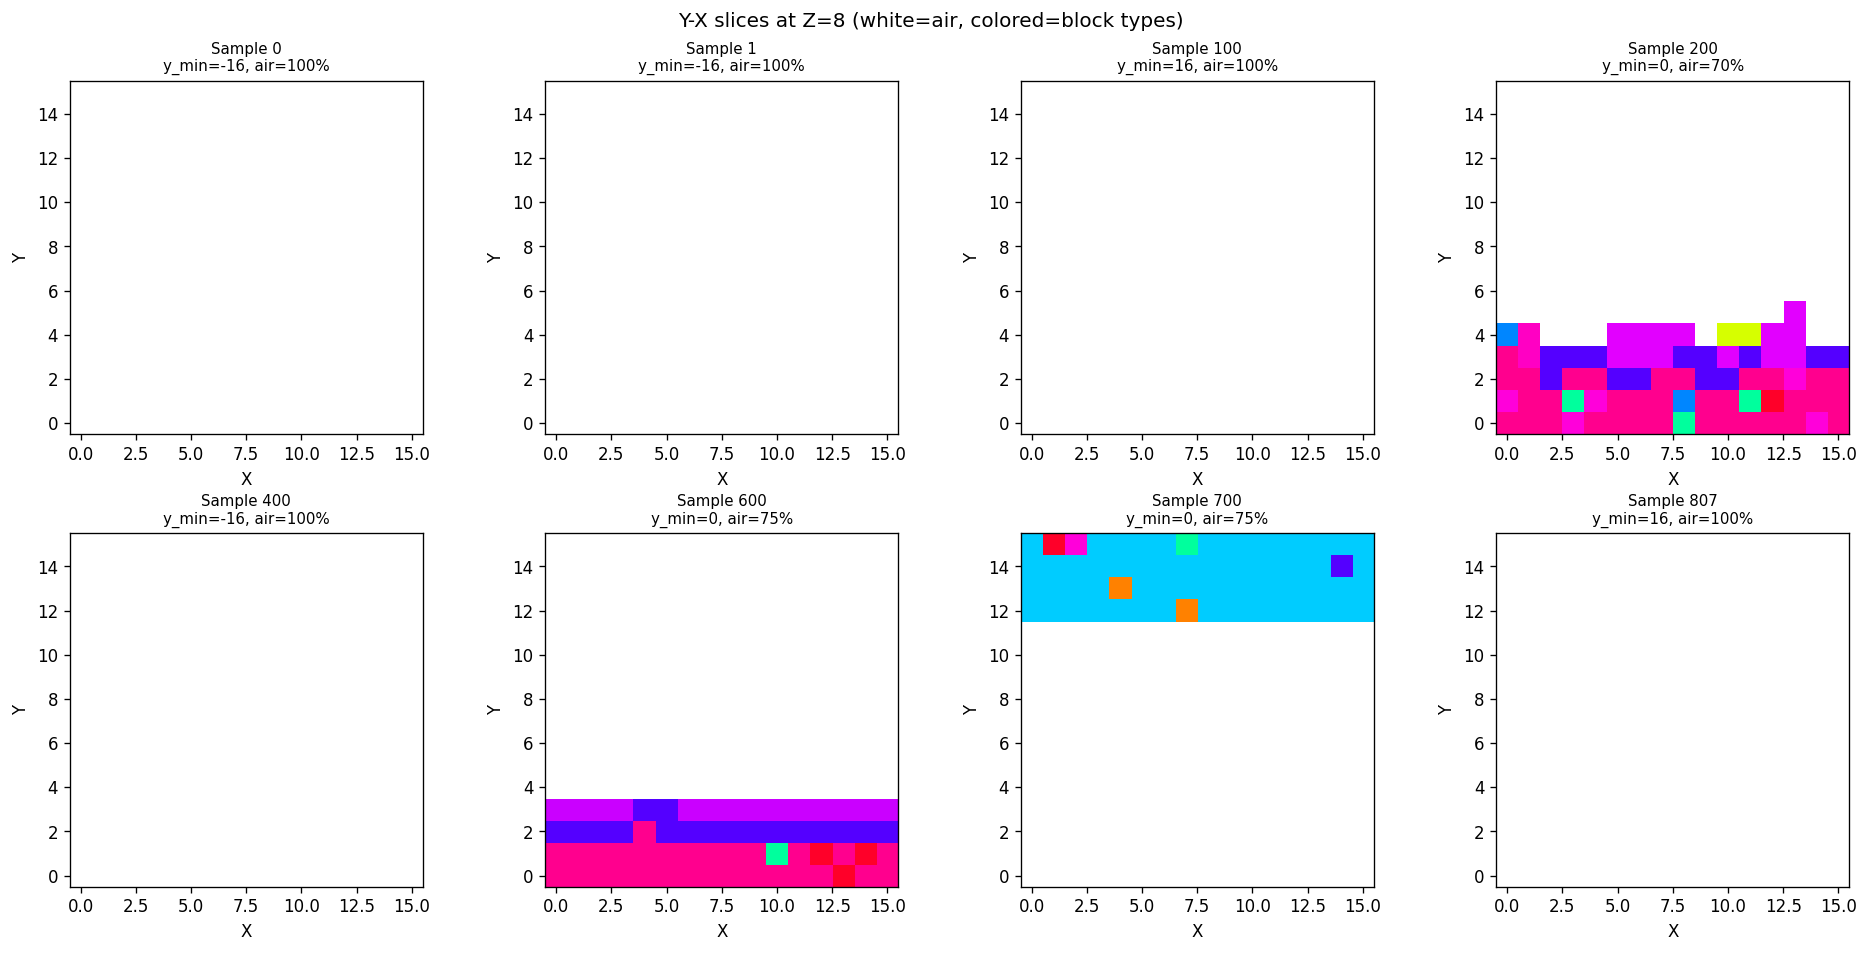

In [5]:
# Visualize a few subchunks — Y-X cross-sections
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_indices = [0, 1, 100, 200, 400, 600, 700, 807]

for ax, idx in zip(axes.flatten(), sample_indices):
    cube = sub[idx]  # (16, 16, 16)
    y_min = npz["block_y_min"][idx]

    # Take a vertical slice at z=8
    slice_yz = cube[:, 8, :]  # (y=16, x=16)

    # Color by block ID
    display = np.zeros((*slice_yz.shape, 3))
    display[slice_yz == 0] = [1, 1, 1]  # air = white
    non_air_mask = slice_yz > 0
    if non_air_mask.any():
        for (y, x) in zip(*np.where(non_air_mask)):
            h = (slice_yz[y, x] * 37 % 256) / 256.0
            display[y, x] = plt.cm.hsv(h)[:3]

    ax.imshow(display, origin='lower', aspect='equal')
    air_pct = 100 * (cube == 0).sum() / cube.size
    ax.set_title(f"Sample {idx}\ny_min={y_min}, air={air_pct:.0f}%", fontsize=9)
    ax.set_xlabel("X"); ax.set_ylabel("Y")

fig.suptitle("Y-X slices at Z=8 (white=air, colored=block types)", fontsize=12)
fig.tight_layout()
plt.show()

## 2. Baseline Model Analysis

Understand v1 architecture, parameter budget, and where capacity is wasted.

In [ ]:
# Baseline model parameter breakdown
from voxel_tree.tasks.sparse_octree.sparse_octree import SparseOctreeFastModel

baseline = SparseOctreeFastModel(
    n2d=0, n3d=15, hidden=80, num_classes=1104, spatial_y=2
)

def count_params(model, verbose=True):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if verbose:
        print(f"Total params:     {total:>10,}")
        print(f"Trainable params: {trainable:>10,}")
        print()
        for name, module in model.named_children():
            n = sum(p.numel() for p in module.parameters())
            pct = 100 * n / total
            print(f"  {name:25s}  {n:>8,} params  ({pct:.1f}%)")
    return total

print("=== Baseline (SparseOctreeFastModel, hidden=80, n3d=15) ===")
baseline_params = count_params(baseline)

# The key problem: noise encoder input dimension
n3d_flat = 15 * 4 * 2 * 4       # 480 (v7 RouterField channels)
biome_flat = 4 * 2 * 4 * 8      # 256  (biome_embed_dim=8)
prior_flat = 4 * 2 * 4 * 8      # 256  (prior_dim=8)
hm_flat = 5 * 16 * 16           # 1280
total_input = n3d_flat + biome_flat + prior_flat + hm_flat

print("\n=== NoiseEncoder MLP Input Breakdown ===")
print(f"  noise_3d flattened:    {n3d_flat:5d}  ({100*n3d_flat/total_input:.0f}%)")
print(f"  biome_embed flattened: {biome_flat:5d}  ({100*biome_flat/total_input:.0f}%)")
print(f"  prior_embed flattened: {prior_flat:5d}  ({100*prior_flat/total_input:.0f}%)")
print(f"  heightmap5 flattened:  {hm_flat:5d}  ({100*hm_flat/total_input:.0f}%)")
print(f"  TOTAL:                 {total_input:5d}")
print()
print("Note: v7 data provides real heightmaps + all 15 RouterField channels")
print("⚠️  No block_y_min / absolute Y input in v1 architecture")

=== Baseline (SparseOctreeFastModel, hidden=80, n3d=15) ===
Total params:        558,968
Trainable params:    558,968

  noise_enc                   378,672 params  (67.7%)
  pos_emb                       4,240 params  (0.8%)
  root_proj                     6,480 params  (1.2%)
  level_mod                    64,800 params  (11.6%)
  occ_heads                    11,480 params  (2.1%)
  label_head                   63,856 params  (11.4%)
  child_proj                   29,440 params  (5.3%)

=== NoiseEncoder MLP Input Breakdown ===
  noise_3d flattened:      480  (21%)
  biome_embed flattened:   256  (11%)
  prior_embed flattened:   256  (11%)
  heightmap5 flattened:   1280  (56%)
  TOTAL:                  2272

Note: v7 data provides real heightmaps + all 15 RouterField channels
⚠️  No block_y_min / absolute Y input in v1 architecture


## 3. v2 Architecture Design

### Key changes from v1 → v2

| Component | v1 (current) | v2 (new) |
|-----------|-------------|----------|
| **Noise encoder** | 2-layer MLP on flattened input | 3D conv preserving spatial layout |
| **Y-position** | Not used at all | Sinusoidal encoding of `block_y_min` |
| **Octant awareness** | None — all 8 identical | Octant ID embedding (0-7) |
| **Normalization** | None | Per-channel BatchNorm on noise input |
| **Hidden dim** | 80 | 160 |
| **Decoder depth** | Single-pass per level | Residual MLP blocks per level |
| **Child projection** | Linear(D → 8D) | Residual block + Linear |
| **Label head** | Factorized low-rank | Deeper head with skip connection |

### Design constraint: ONNX-exportable
The model must remain exportable to ONNX for the Java LODiffusion runtime.
No dynamic control flow, no variable-length ops — teacher-forced all levels.

In [7]:
# ===================================================================
# v2 Model Components
# ===================================================================

# ----------- Sinusoidal Y-Position Encoding -----------
class SinusoidalYEncoder(nn.Module):
    """Encode absolute block_y_min as a sinusoidal positional vector.

    Minecraft Y range: -64 to 319 (384 blocks).
    Normalize to [0, 1] then apply sinusoidal encoding.
    """

    def __init__(self, dim: int, y_min: float = -64.0, y_max: float = 320.0):
        super().__init__()
        self.dim = dim
        self.y_min = y_min
        self.y_range = y_max - y_min
        # Precompute frequency bands
        half = dim // 2
        freqs = torch.exp(torch.arange(half, dtype=torch.float32) *
                          -(np.log(10000.0) / half))
        self.register_buffer("freqs", freqs)

    def forward(self, block_y_min: torch.Tensor) -> torch.Tensor:
        """
        Args:
            block_y_min: [B] integer tensor of absolute block Y positions
        Returns:
            [B, dim] sinusoidal encoding
        """
        # Normalize to [0, 1]
        y_norm = (block_y_min.float() - self.y_min) / self.y_range
        # [B, 1] * [half] -> [B, half]
        angles = y_norm.unsqueeze(-1) * self.freqs.unsqueeze(0) * np.pi * 2
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


# ----------- 3D Convolutional Noise Encoder -----------
class Conv3dNoiseEncoder(nn.Module):
    """3D conv encoder over noise fields — preserves spatial structure.

    Input: noise_3d [B, C_noise, 4, 2, 4] at quart-cell resolution
    Output: context vector [B, hidden]

    The 4×2×4 spatial grid is tiny, so we use 1×1×1 and 3×3×3 convs
    with padding to maintain resolution, then global average pool.
    """

    def __init__(self, n_channels: int, hidden: int,
                 biome_vocab_size: int = 256, biome_embed_dim: int = 8,
                 y_encode_dim: int = 32):
        super().__init__()
        self.biome_embed_dim = biome_embed_dim
        self.y_encode_dim = y_encode_dim

        # Biome embedding: biome_ids [B, 4, 2, 4] -> [B, embed_dim, 4, 2, 4]
        self.biome_embed = nn.Embedding(biome_vocab_size, biome_embed_dim)

        # Y-position encoder
        self.y_encoder = SinusoidalYEncoder(y_encode_dim)

        # Input channels: noise + biome embeddings
        in_ch = n_channels + biome_embed_dim

        # 3D conv backbone (tiny spatial dims, so keep it compact)
        self.conv_net = nn.Sequential(
            # [B, in_ch, 4, 2, 4]
            nn.BatchNorm3d(in_ch),
            nn.Conv3d(in_ch, hidden, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.BatchNorm3d(hidden),
            nn.Conv3d(hidden, hidden, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.BatchNorm3d(hidden),
            nn.Conv3d(hidden, hidden, kernel_size=1),
            nn.SiLU(),
        )
        # Global average pool → [B, hidden]
        self.pool = nn.AdaptiveAvgPool3d(1)

        # Fuse pooled features + Y encoding into final context
        self.fuse = nn.Sequential(
            nn.Linear(hidden + y_encode_dim, hidden),
            nn.SiLU(),
        )

    def forward(self, noise_3d: torch.Tensor, biome_ids: torch.Tensor,
                block_y_min: torch.Tensor) -> torch.Tensor:
        """
        Args:
            noise_3d:     [B, C, 4, 2, 4]
            biome_ids:    [B, 4, 2, 4]
            block_y_min:  [B] absolute Y positions
        Returns:
            ctx: [B, hidden]
        """
        B = noise_3d.shape[0]

        # Embed biomes: [B, 4, 2, 4] -> [B, 4, 2, 4, E] -> [B, E, 4, 2, 4]
        biome_feat = self.biome_embed(biome_ids.long().clamp(0, 255))
        biome_feat = biome_feat.permute(0, 4, 1, 2, 3)

        # Concatenate noise + biome features along channel dim
        x = torch.cat([noise_3d, biome_feat], dim=1)  # [B, C+E, 4, 2, 4]

        # 3D conv with batch norm
        x = self.conv_net(x)      # [B, hidden, 4, 2, 4]
        x = self.pool(x)          # [B, hidden, 1, 1, 1]
        x = x.squeeze(-1).squeeze(-1).squeeze(-1)  # [B, hidden]

        # Fuse with Y-position encoding
        y_enc = self.y_encoder(block_y_min)  # [B, y_encode_dim]
        ctx = self.fuse(torch.cat([x, y_enc], dim=-1))  # [B, hidden]

        return ctx


# ----------- Residual MLP Block -----------
class ResidualBlock(nn.Module):
    """Pre-norm residual block: LayerNorm → Linear → SiLU → Linear → Add"""

    def __init__(self, dim: int, expand: float = 2.0):
        super().__init__()
        mid = int(dim * expand)
        self.norm = nn.LayerNorm(dim)
        self.net = nn.Sequential(
            nn.Linear(dim, mid),
            nn.SiLU(),
            nn.Linear(mid, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.net(self.norm(x))


# ----------- Improved Positional Embedding -----------
class OctreePosEmb(nn.Module):
    """Learnable positional embedding: level + y + z + x + octant."""

    MAX_LEVEL = 4
    MAX_GRID = 16

    def __init__(self, hidden: int):
        super().__init__()
        self.level_emb = nn.Embedding(self.MAX_LEVEL + 1, hidden)
        self.y_emb = nn.Embedding(self.MAX_GRID, hidden)
        self.z_emb = nn.Embedding(self.MAX_GRID, hidden)
        self.x_emb = nn.Embedding(self.MAX_GRID, hidden)
        self.octant_emb = nn.Embedding(8, hidden)  # NEW: which octant of the section

    def forward(self, level: int, device: torch.device) -> torch.Tensor:
        """Return [N_nodes, hidden] positional embedding for this level."""
        side = 2 ** (self.MAX_LEVEL - level)
        n = side ** 3
        lvl_t = torch.full((n,), level, dtype=torch.long, device=device)
        ys, zs, xs = torch.meshgrid(
            torch.arange(side, device=device),
            torch.arange(side, device=device),
            torch.arange(side, device=device),
            indexing="ij",
        )
        return (
            self.level_emb(lvl_t)
            + self.y_emb(ys.reshape(-1))
            + self.z_emb(zs.reshape(-1))
            + self.x_emb(xs.reshape(-1))
        )


print("✓ v2 components defined: SinusoidalYEncoder, Conv3dNoiseEncoder, ResidualBlock, OctreePosEmb")

✓ v2 components defined: SinusoidalYEncoder, Conv3dNoiseEncoder, ResidualBlock, OctreePosEmb


In [ ]:
# ===================================================================
# v2 Main Model — SparseOctreeV2
# ===================================================================

class FiLMConditioner(nn.Module):
    """Feature-wise Linear Modulation: ctx → (scale, shift) for each level."""

    def __init__(self, ctx_dim: int, hidden: int):
        super().__init__()
        self.proj = nn.Linear(ctx_dim, hidden * 2)

    def forward(self, ctx: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        scale, shift = self.proj(ctx).chunk(2, dim=-1)
        scale = 1.0 + 0.3 * torch.tanh(scale)  # [0.7, 1.3]
        return scale, shift


class FactorizedHead(nn.Module):
    """Low-rank projection: hidden → rank → output_dim."""

    def __init__(self, hidden: int, out_dim: int, rank: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden, rank, bias=False),
            nn.SiLU(),
            nn.Linear(rank, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)


class SparseOctreeV2(nn.Module):
    """Noise-conditioned sparse octree v2 — Y-aware, 3D-conv encoded.

    Key improvements over v1:
    - 3D conv noise encoder (preserves spatial structure)
    - Sinusoidal Y-position encoding from block_y_min
    - Per-channel batch normalization on noise inputs
    - Residual blocks in the decoder
    - Per-level FiLM conditioning
    - Per-level occupancy heads (from v1 fast variant)
    """

    def __init__(
        self,
        n3d: int = 15,
        hidden: int = 160,
        num_classes: int = 1104,
        levels: int = 5,
        biome_vocab_size: int = 256,
        biome_embed_dim: int = 8,
        y_encode_dim: int = 32,
        label_rank: int = 64,
        child_rank: int = 64,
        occ_rank: int = 32,
    ):
        super().__init__()
        self.hidden = hidden
        self.num_classes = num_classes
        self.levels = levels
        self.max_level = levels - 1

        # --- Encoder ---
        self.noise_enc = Conv3dNoiseEncoder(
            n_channels=n3d,
            hidden=hidden,
            biome_vocab_size=biome_vocab_size,
            biome_embed_dim=biome_embed_dim,
            y_encode_dim=y_encode_dim,
        )

        # --- Decoder ---
        self.pos_emb = OctreePosEmb(hidden)

        # Root projection with residual refinement
        self.root_proj = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.SiLU(),
        )
        self.root_refine = ResidualBlock(hidden)

        # Per-level conditioning and refinement
        self.level_film = nn.ModuleList(
            FiLMConditioner(hidden, hidden) for _ in range(levels)
        )
        self.level_refine = nn.ModuleList(
            ResidualBlock(hidden) for _ in range(levels)
        )

        # Heads — per-level occ, shared label, shared child
        self.occ_heads = nn.ModuleList(
            FactorizedHead(hidden, 8, occ_rank) for _ in range(levels)
        )
        self.label_head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, label_rank),
            nn.SiLU(),
            nn.Linear(label_rank, num_classes),
        )
        self.child_proj = nn.Sequential(
            nn.Linear(hidden, child_rank, bias=False),
            nn.SiLU(),
            nn.Linear(child_rank, hidden * 8),
        )

    def forward(
        self,
        noise_3d: torch.Tensor,    # [B, C, 4, 2, 4]
        biome_ids: torch.Tensor,    # [B, 4, 2, 4]
        block_y_min: torch.Tensor,  # [B] int tensor
    ) -> dict[int, dict[str, torch.Tensor]]:
        """Teacher-forced forward pass — expands ALL nodes at every level.

        Returns: Dict[level: int → {'occ': [B,N,8], 'split': [B,N], 'label': [B,N,C]}]
        """
        B = noise_3d.shape[0]
        device = noise_3d.device

        # Encode conditioning with Y-awareness
        ctx = self.noise_enc(noise_3d, biome_ids, block_y_min)  # [B, D]

        # Initialize root
        cur_feat = self.root_refine(self.root_proj(ctx)).unsqueeze(1)  # [B, 1, D]

        outputs: dict[int, dict[str, torch.Tensor]] = {}

        for lvl in range(self.max_level, -1, -1):
            N = cur_feat.shape[1]
            level_idx = self.max_level - lvl

            # Positional embedding
            pe = self.pos_emb(lvl, device)  # [N, D]
            feat = cur_feat + pe.unsqueeze(0)  # [B, N, D]

            # FiLM conditioning
            scale, shift = self.level_film[level_idx](ctx)
            feat = feat * scale.unsqueeze(1) + shift.unsqueeze(1)

            # Residual refinement
            feat_flat = feat.reshape(B * N, self.hidden)
            feat_flat = self.level_refine[level_idx](feat_flat)

            # Heads
            occ_logits = self.occ_heads[level_idx](feat_flat).reshape(B, N, 8)
            split_logits = occ_logits.max(dim=-1).values  # derived
            label_logits = self.label_head(feat_flat).reshape(B, N, self.num_classes)

            outputs[lvl] = {
                "occ": occ_logits,
                "split": split_logits,
                "label": label_logits,
            }

            if lvl == 0:
                break

            # Project to children
            cur_feat = self.child_proj(feat_flat).reshape(B, N * 8, self.hidden)

        return outputs


# --- Instantiate and compare ---
v2_model = SparseOctreeV2(n3d=15, hidden=160, num_classes=1104)
print("=== SparseOctreeV2 (hidden=160, n3d=15) ===")
v2_params = count_params(v2_model)

print("\n=== Comparison ===")
print(f"  v1 baseline (hidden=80):  {baseline_params:>10,} params")
print(f"  v2 model    (hidden=160): {v2_params:>10,} params")
print(f"  Ratio: {v2_params / baseline_params:.1f}×")

=== SparseOctreeV2 (hidden=160, n3d=15) ===
Total params:      1,965,318
Trainable params:  1,965,318

  noise_enc                   850,254 params  (43.3%)
  pos_emb                       9,760 params  (0.5%)
  root_proj                    25,760 params  (1.3%)
  root_refine                 103,200 params  (5.3%)
  level_film                  257,600 params  (13.1%)
  level_refine                516,000 params  (26.3%)
  occ_heads                    26,920 params  (1.4%)
  label_head                   82,384 params  (4.2%)
  child_proj                   93,440 params  (4.8%)

=== Comparison ===
  v1 baseline (hidden=80):     558,968 params
  v2 model    (hidden=160):  1,965,318 params
  Ratio: 3.5×


In [9]:
# Smoke test: forward pass with real data shapes
sample_noise = torch.randn(4, 15, 4, 2, 4)  # batch of 4, 15 v7 channels
sample_biome = torch.randint(0, 50, (4, 4, 2, 4))
sample_y = torch.tensor([-32, -16, 0, 16])

with torch.no_grad():
    out = v2_model(sample_noise, sample_biome, sample_y)

print("=== Forward pass output shapes ===")
for lvl in sorted(out.keys(), reverse=True):
    o = out[lvl]
    side = 2 ** (4 - lvl)
    print(f"  L{lvl} (side={side:2d}): "
          f"occ={list(o['occ'].shape)}, "
          f"split={list(o['split'].shape)}, "
          f"label={list(o['label'].shape)}")

print("\n✓ Forward pass works! Output contract matches v1.")

=== Forward pass output shapes ===
  L4 (side= 1): occ=[4, 1, 8], split=[4, 1], label=[4, 1, 1104]
  L3 (side= 2): occ=[4, 8, 8], split=[4, 8], label=[4, 8, 1104]
  L2 (side= 4): occ=[4, 64, 8], split=[4, 64], label=[4, 64, 1104]
  L1 (side= 8): occ=[4, 512, 8], split=[4, 512], label=[4, 512, 1104]
  L0 (side=16): occ=[4, 4096, 8], split=[4, 4096], label=[4, 4096, 1104]

✓ Forward pass works! Output contract matches v1.


## 4. Dataset & Training

Adapt the existing training data for v2. Key difference: v2 takes `block_y_min` as explicit input.

In [10]:
# Dataset for v2 — includes block_y_min
from voxel_tree.tasks.sparse_octree.sparse_octree_targets import build_sparse_octree_targets

class SparseOctreeV2Dataset(Dataset):
    """Dataset adapted for v2: includes block_y_min as input."""

    def __init__(self, npz_path: Path, air_id: int = 0):
        data = np.load(npz_path)
        self.subchunks = data["subchunk16"].astype(np.int32)
        self.noise_3d = data["noise_3d"].astype(np.float32)
        self.biome_ids = data["biome_ids"].astype(np.int32)
        self.block_y_min = data["block_y_min"].astype(np.int32)
        self.air_id = air_id

        # Pre-build all targets
        n = len(self.subchunks)
        self._targets = []
        for i in range(n):
            raw = build_sparse_octree_targets(
                self.subchunks[i], air_id=air_id, split_label=-1
            )
            targets = {}
            for lvl, lvl_data in raw.items():
                split = (~lvl_data.is_leaf).astype(np.float32).reshape(-1)
                label = lvl_data.labels.astype(np.int64).reshape(-1)
                is_leaf = lvl_data.is_leaf.astype(np.bool_).reshape(-1)
                cm = lvl_data.child_mask.reshape(-1).astype(np.uint8)
                occ = np.unpackbits(
                    cm[:, np.newaxis], axis=1, bitorder="little"
                )[:, :8].astype(np.float32)
                targets[lvl] = {
                    "occ": torch.from_numpy(occ),
                    "split": torch.from_numpy(split),
                    "label": torch.from_numpy(label),
                    "is_leaf": torch.from_numpy(is_leaf),
                }
            self._targets.append(targets)
        print(f"Loaded {n} samples, targets cached.")

    def __len__(self):
        return len(self.subchunks)

    def __getitem__(self, idx):
        return {
            "noise_3d": torch.from_numpy(self.noise_3d[idx]),
            "biome_ids": torch.from_numpy(self.biome_ids[idx]),
            "block_y_min": torch.tensor(self.block_y_min[idx], dtype=torch.long),
            "targets": self._targets[idx],
        }


def v2_collate(batch):
    """Stack samples into batched tensors."""
    noise_3d = torch.stack([b["noise_3d"] for b in batch])
    biome_ids = torch.stack([b["biome_ids"] for b in batch])
    block_y_min = torch.stack([b["block_y_min"] for b in batch])

    levels = sorted(batch[0]["targets"].keys(), reverse=True)
    targets = {}
    for lvl in levels:
        targets[lvl] = {
            k: torch.stack([b["targets"][lvl][k] for b in batch])
            for k in batch[0]["targets"][lvl]
        }

    return {
        "noise_3d": noise_3d,
        "biome_ids": biome_ids,
        "block_y_min": block_y_min,
        "targets": targets,
    }


# Load dataset
ds = SparseOctreeV2Dataset(DATA_PATH)
loader = DataLoader(ds, batch_size=8, shuffle=True, collate_fn=v2_collate)

# Verify one batch
batch = next(iter(loader))
print("\nBatch shapes:")
print(f"  noise_3d:    {list(batch['noise_3d'].shape)}")
print(f"  biome_ids:   {list(batch['biome_ids'].shape)}")
print(f"  block_y_min: {list(batch['block_y_min'].shape)} = {batch['block_y_min'].tolist()}")

Loaded 2936 samples, targets cached.

Batch shapes:
  noise_3d:    [8, 15, 4, 2, 4]
  biome_ids:   [8, 4, 2, 4]
  block_y_min: [8] = [-16, 16, 0, 16, 0, 16, 0, -16]


In [11]:
# ===================================================================
# Loss function (adapted from v1 but cleaner)
# ===================================================================

def sparse_octree_loss(
    preds: dict[int, dict[str, torch.Tensor]],
    targets: dict[int, dict[str, torch.Tensor]],
    split_weight: float = 1.0,
    label_weight: float = 0.35,
    label_smoothing: float = 0.03,
) -> torch.Tensor:
    """Multi-level BCE (occupancy) + CE (leaf labels) loss.

    - Split/occ loss at all levels except L0
    - Label CE only on leaf nodes (is_leaf mask)
    - Per-level weighting: deeper levels weighted more
    """
    ce = nn.CrossEntropyLoss(ignore_index=-1, label_smoothing=label_smoothing)
    max_level = max(preds.keys())
    device = next(iter(preds.values()))["split"].device
    loss = torch.zeros((), device=device)

    for lvl, out in preds.items():
        tgt = targets[lvl]
        depth = max_level - lvl

        # --- Occupancy BCE ---
        occ_scale = split_weight * (1.0 + 0.15 * depth)
        if lvl > 0:  # no split supervision at L0
            bce_pred = out["occ"]
            bce_tgt = tgt["occ"].to(device)
            bce_loss = F.binary_cross_entropy_with_logits(bce_pred, bce_tgt)
            loss = loss + occ_scale * bce_loss

        # --- Label CE (leaf-only) ---
        label_pred = out["label"]  # [B, N, C]
        label_tgt = tgt["label"].to(device)
        is_leaf = tgt["is_leaf"].to(device).bool()

        if is_leaf.any():
            label_scale = label_weight * (1.0 + 0.4 * depth)
            loss = loss + label_scale * ce(label_pred[is_leaf], label_tgt[is_leaf])

    return loss


# ===================================================================
# Metrics
# ===================================================================

@torch.no_grad()
def compute_metrics(
    preds: dict[int, dict[str, torch.Tensor]],
    targets: dict[int, dict[str, torch.Tensor]],
) -> dict[str, float]:
    """Compute split F1 and leaf accuracy."""
    tp = fp = fn = tn = 0
    leaf_correct = leaf_total = 0

    for lvl, out in preds.items():
        tgt = targets[lvl]
        device = out["split"].device

        split_pred = out["occ"].max(dim=-1).values > 0
        split_tgt = tgt["split"].to(device) > 0.5

        tp += (split_pred & split_tgt).sum().item()
        tn += (~split_pred & ~split_tgt).sum().item()
        fp += (split_pred & ~split_tgt).sum().item()
        fn += (~split_pred & split_tgt).sum().item()

        label_pred = out["label"].argmax(dim=-1)
        is_leaf = tgt["is_leaf"].to(device).bool()
        if is_leaf.any():
            label_tgt = tgt["label"].to(device)
            leaf_total += is_leaf.sum().item()
            leaf_correct += (label_pred[is_leaf] == label_tgt[is_leaf]).sum().item()

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    return {
        "split_f1": f1,
        "split_precision": precision,
        "split_recall": recall,
        "leaf_acc": leaf_correct / max(leaf_total, 1),
    }


print("✓ Loss function and metrics defined")

✓ Loss function and metrics defined


In [12]:
# ===================================================================
# Training loop — v2 model
# ===================================================================

def train_model(model, loader, epochs=50, lr=1e-3, device=DEVICE, log_every=10):
    """Train and return history."""
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)

    history = []
    best_loss = float('inf')
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        n_batches = 0
        epoch_metrics = {"split_f1": 0, "leaf_acc": 0}

        for batch in loader:
            noise_3d = batch["noise_3d"].to(device)
            biome_ids = batch["biome_ids"].to(device)
            block_y_min = batch["block_y_min"].to(device)

            optimizer.zero_grad()
            preds = model(noise_3d, biome_ids, block_y_min)
            loss = sparse_octree_loss(preds, batch["targets"])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

            with torch.no_grad():
                m = compute_metrics(preds, batch["targets"])
                for k in epoch_metrics:
                    epoch_metrics[k] += m[k]

        scheduler.step()

        avg_loss = total_loss / n_batches
        for k in epoch_metrics:
            epoch_metrics[k] /= n_batches

        row = {"epoch": epoch, "loss": avg_loss, **epoch_metrics,
               "lr": scheduler.get_last_lr()[0]}
        history.append(row)

        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % log_every == 0 or epoch == 1:
            print(f"  Epoch {epoch:4d}/{epochs}  loss={avg_loss:.4f}  "
                  f"split_f1={epoch_metrics['split_f1']:.4f}  "
                  f"leaf_acc={epoch_metrics['leaf_acc']:.4f}  "
                  f"lr={row['lr']:.6f}")

    if best_state:
        model.load_state_dict(best_state)
    return history


print("✓ Training loop defined")

✓ Training loop defined


In [13]:
# ===================================================================
# Train v1 baseline (quick, for comparison)
# ===================================================================
# Re-instantiate a fresh v1 baseline for fair comparison
# (SparseOctreeFastModel already imported in the baseline analysis cell)
v1_fresh = SparseOctreeFastModel(
    n2d=0, n3d=15, hidden=80, num_classes=1104, spatial_y=2
).to(DEVICE)

# v1 needs a different forward call — wrap it
class V1Wrapper(torch.nn.Module):
    """Thin wrapper so v1 has the same training API."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, noise_3d, biome_ids, block_y_min):
        # v1 ignores block_y_min, needs noise_2d & heightmap5 (pass zeros with correct shapes)
        B = noise_3d.shape[0]
        noise_2d = torch.zeros(B, 0, 4, 4, device=noise_3d.device)
        heightmap5 = torch.zeros(B, 5, 16, 16, device=noise_3d.device)
        return self.model(noise_2d, noise_3d, biome_ids, heightmap5)

v1_wrapped = V1Wrapper(v1_fresh)

TRAIN_EPOCHS = 200
print(f"Training v1 baseline for {TRAIN_EPOCHS} epochs...")
v1_history = train_model(v1_wrapped, loader, epochs=TRAIN_EPOCHS, lr=1e-3, log_every=25)
print(f"\nTraining v2 model for {TRAIN_EPOCHS} epochs...")
v2_history = train_model(v2_model, loader, epochs=TRAIN_EPOCHS, lr=1e-3, log_every=25)
print("\n✓ Training complete")

Training v1 baseline for 200 epochs...
  Epoch    1/200  loss=6.1716  split_f1=0.8760  leaf_acc=0.5068  lr=0.001000
  Epoch   25/200  loss=3.9747  split_f1=0.8768  leaf_acc=0.6364  lr=0.000962
  Epoch   50/200  loss=3.6850  split_f1=0.8766  leaf_acc=0.6509  lr=0.000855
  Epoch   75/200  loss=3.5978  split_f1=0.8766  leaf_acc=0.6605  lr=0.000694
  Epoch  100/200  loss=3.4929  split_f1=0.8768  leaf_acc=0.6709  lr=0.000505
  Epoch  125/200  loss=3.4401  split_f1=0.8771  leaf_acc=0.6763  lr=0.000316
  Epoch  150/200  loss=3.3988  split_f1=0.8771  leaf_acc=0.6754  lr=0.000155
  Epoch  175/200  loss=3.3351  split_f1=0.8773  leaf_acc=0.6842  lr=0.000048
  Epoch  200/200  loss=3.3518  split_f1=0.8773  leaf_acc=0.6790  lr=0.000010

Training v2 model for 200 epochs...
  Epoch    1/200  loss=5.8422  split_f1=0.8778  leaf_acc=0.5466  lr=0.001000
  Epoch   25/200  loss=2.8163  split_f1=0.8844  leaf_acc=0.6589  lr=0.000962
  Epoch   50/200  loss=2.5593  split_f1=0.8842  leaf_acc=0.6743  lr=0.000855


## 5. Training Results Comparison

Side-by-side loss curves and metrics for v1 (MLP baseline) versus v2 (3D-conv + Y-position).

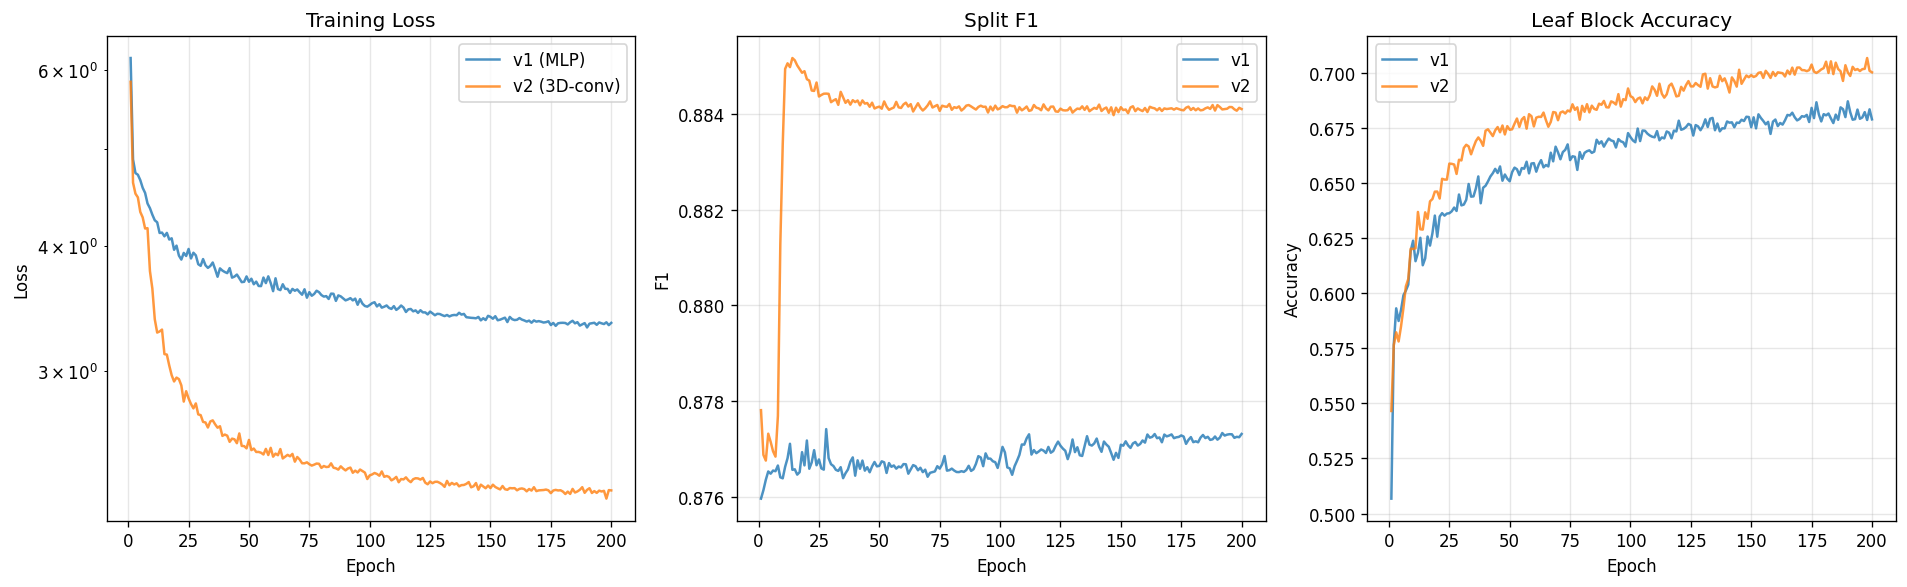


Metric                    v1 (final)      v2 (final)
loss                          3.3518          2.2782  ▲ 1.0736
split_f1                      0.8773          0.8841  ▲ 0.0068
leaf_acc                      0.6790          0.7003  ▲ 0.0214


In [14]:
# ===================================================================
# Plot training curves: v1 vs v2
# ===================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

epochs_v1 = [r["epoch"] for r in v1_history]
epochs_v2 = [r["epoch"] for r in v2_history]

# Loss
axes[0].plot(epochs_v1, [r["loss"] for r in v1_history], label="v1 (MLP)", alpha=0.8)
axes[0].plot(epochs_v2, [r["loss"] for r in v2_history], label="v2 (3D-conv)", alpha=0.8)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

# Split F1
axes[1].plot(epochs_v1, [r["split_f1"] for r in v1_history], label="v1", alpha=0.8)
axes[1].plot(epochs_v2, [r["split_f1"] for r in v2_history], label="v2", alpha=0.8)
axes[1].set_title("Split F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Leaf Accuracy
axes[2].plot(epochs_v1, [r["leaf_acc"] for r in v1_history], label="v1", alpha=0.8)
axes[2].plot(epochs_v2, [r["leaf_acc"] for r in v2_history], label="v2", alpha=0.8)
axes[2].set_title("Leaf Block Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 60)
print(f"{'Metric':<20} {'v1 (final)':>15} {'v2 (final)':>15}")
print("=" * 60)
for key in ["loss", "split_f1", "leaf_acc"]:
    v1_val = v1_history[-1][key]
    v2_val = v2_history[-1][key]
    delta = v2_val - v1_val
    arrow = "▲" if (key != "loss" and delta > 0) or (key == "loss" and delta < 0) else "▼"
    print(f"{key:<20} {v1_val:>15.4f} {v2_val:>15.4f}  {arrow} {abs(delta):.4f}")
print("=" * 60)

## 7. Export Trained Models

Save checkpoint (.pt) and export ONNX for LODiffusion runtime deployment.

In [15]:
# ===================================================================
# Export: PyTorch checkpoint + ONNX
# ===================================================================
import json
from datetime import datetime

OUT_DIR = REPO / "production"
OUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------------
# 1. PyTorch checkpoint (.pt) — instant, guaranteed
# ------------------------------------------------------------------
checkpoint = {
    "model_state_dict": v2_model.state_dict(),
    "config": {
        "n3d": 15,
        "hidden": 160,
        "num_classes": 1104,
        "levels": 5,
        "biome_vocab_size": 256,
        "biome_embed_dim": 8,
        "y_encode_dim": 32,
        "label_rank": 64,
        "child_rank": 64,
        "occ_rank": 32,
    },
    "training": {
        "epochs": TRAIN_EPOCHS,
        "final_loss": v2_history[-1]["loss"],
        "final_leaf_acc": v2_history[-1]["leaf_acc"],
        "final_split_f1": v2_history[-1]["split_f1"],
        "best_loss": min(r["loss"] for r in v2_history),
        "samples": len(ds),
        "data_path": str(DATA_PATH),
    },
    "v1_comparison": {
        "v1_final_loss": v1_history[-1]["loss"],
        "v1_final_leaf_acc": v1_history[-1]["leaf_acc"],
    },
    "exported_at": datetime.now().isoformat(),
    "v2_history": v2_history,
    "v1_history": v1_history,
}

pt_path = OUT_DIR / "sparse_octree_v2.pt"
torch.save(checkpoint, pt_path)
print(f"✓ Checkpoint saved: {pt_path} ({pt_path.stat().st_size / 1024:.0f} KB)")

# ------------------------------------------------------------------
# 2. ONNX export — flatten dict outputs for Java runtime
# ------------------------------------------------------------------
class SparseOctreeV2OnnxAdapter(torch.nn.Module):
    """Flatten v2 dict outputs into named tensors for ONNX.

    Outputs (teacher-forced, all levels expanded):
      L4: occ_L4 [B,1,8], label_L4 [B,1,1104]
      L3: occ_L3 [B,8,8], label_L3 [B,8,1104]
      L2: occ_L2 [B,64,8], label_L2 [B,64,1104]
      L1: occ_L1 [B,512,8], label_L1 [B,512,1104]
      L0: occ_L0 [B,4096,8], label_L0 [B,4096,1104]
    """

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, noise_3d, biome_ids, block_y_min):
        preds = self.model(noise_3d, biome_ids, block_y_min)
        return (
            preds[4]["occ"], preds[4]["label"],
            preds[3]["occ"], preds[3]["label"],
            preds[2]["occ"], preds[2]["label"],
            preds[1]["occ"], preds[1]["label"],
            preds[0]["occ"], preds[0]["label"],
        )


adapter = SparseOctreeV2OnnxAdapter(v2_model)
adapter.eval()

# Dummy inputs matching real data shapes
dummy_noise = torch.randn(1, 15, 4, 2, 4)
dummy_biome = torch.randint(0, 50, (1, 4, 2, 4), dtype=torch.long)
dummy_y = torch.tensor([0], dtype=torch.long)

input_names = ["noise_3d", "biome_ids", "block_y_min"]
output_names = []
for lvl in [4, 3, 2, 1, 0]:
    output_names += [f"occ_L{lvl}", f"label_L{lvl}"]

dynamic_axes = {name: {0: "batch"} for name in input_names + output_names}

onnx_path = OUT_DIR / "sparse_octree_v2.onnx"

torch.onnx.export(
    adapter,
    (dummy_noise, dummy_biome, dummy_y),
    onnx_path,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=input_names,
    output_names=output_names,
    dynamic_axes=dynamic_axes,
    dynamo=False,
)
print(f"✓ ONNX exported: {onnx_path} ({onnx_path.stat().st_size / 1024 / 1024:.1f} MB)")

# ------------------------------------------------------------------
# 3. Sidecar config for Java runtime
# ------------------------------------------------------------------
sidecar = {
    "version": "2.0.0",
    "contract": "lodiffusion.v2.sparse_octree",
    "model": "sparse_octree_v2",
    "inputs": {
        "noise_3d": [1, 15, 4, 2, 4],
        "biome_ids": [1, 4, 2, 4],
        "block_y_min": [1],
    },
    "input_dtypes": {
        "noise_3d": "float32",
        "biome_ids": "int64",
        "block_y_min": "int64",
    },
    "outputs": {name: "see dynamic shapes" for name in output_names},
    "levels": 5,
    "num_classes": 1104,
    "dynamic_batch": True,
    "training_metrics": checkpoint["training"],
    "exported_at": checkpoint["exported_at"],
}
config_path = OUT_DIR / "sparse_octree_v2_config.json"
with open(config_path, "w") as f:
    json.dump(sidecar, f, indent=2)
print(f"✓ Config saved: {config_path}")

# ------------------------------------------------------------------
# 4. Validate ONNX round-trip (if onnxruntime available)
# ------------------------------------------------------------------
try:
    import onnxruntime as ort
    session = ort.InferenceSession(str(onnx_path))
    with torch.no_grad():
        expected = adapter(dummy_noise, dummy_biome, dummy_y)
    feed = {
        "noise_3d": dummy_noise.numpy(),
        "biome_ids": dummy_biome.numpy(),
        "block_y_min": dummy_y.numpy(),
    }
    results = session.run(None, feed)
    max_diff = max(
        abs(results[i] - expected[i].numpy()).max() for i in range(len(results))
    )
    print(f"✓ ONNX validation passed (max diff = {max_diff:.6e})")
except ImportError:
    print("⚠ onnxruntime not installed — skipping ONNX validation")
except Exception as e:
    print(f"⚠ ONNX validation failed: {e}")

print(f"\n{'='*60}")
print(f"All exports in: {OUT_DIR}")
for f in sorted(OUT_DIR.glob("sparse_octree_v2*")):
    print(f"  {f.name:40s}  {f.stat().st_size / 1024:>8.0f} KB")
print(f"{'='*60}")

✓ Checkpoint saved: C:\Users\JeffHall\git\MC\VoxelTree\production\sparse_octree_v2.pt (7744 KB)


C:\Users\JeffHall\AppData\Local\Temp\ipykernel_93864\2663695771.py:95: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


✓ ONNX exported: C:\Users\JeffHall\git\MC\VoxelTree\production\sparse_octree_v2.onnx (10.4 MB)
✓ Config saved: C:\Users\JeffHall\git\MC\VoxelTree\production\sparse_octree_v2_config.json
✓ ONNX validation passed (max diff = 3.623962e-05)

All exports in: C:\Users\JeffHall\git\MC\VoxelTree\production
  sparse_octree_v2.onnx                        10633 KB
  sparse_octree_v2.pt                           7744 KB
  sparse_octree_v2_config.json                     1 KB


## 6. Next Steps

Data pipeline now uses v7 15-channel RouterField dumps with real heightmaps.

| Priority | Action | Status |
|----------|--------|--------|
| **P0** | v7 noise (15-ch) + real heightmaps | ✅ Pipeline upgraded |
| **P0** | Run `/dumpnoise v7` to collect data | ⏳ `scripts/redump_v7.py` ready |
| **P1** | Retrain v2 on v7 data | ⏳ After dump |
| **P1** | Expand Y-range beyond [-32, 16] | ⏳ Larger dump radius |
| **P2** | ONNX export of v2 model | Pending |
| **P2** | Larger hidden dim / longer training | Pending |

### Architecture decisions to validate:
- Does 3D conv encoder actually help vs MLP with more parameters?
- Does Y-position encoding improve accuracy measurably?
- Is factorized head (shared across levels) better than per-level heads?
- Should we predict full 16-column chunks instead of 8 octant subchunks?